In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import utils as uti

In [2]:
print(uti.__file__)
print(dir(uti))

/home/jovyan/work/credit-risk/code/utils/__init__.py
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'calculate_auc_statistics', 'calculate_wald_statistics', 'calibration_plot', 'corr_crit', 'cumulative_event_rate_plot', 'forward_select_auc', 'ks_plot', 'model', 'plot_event_cat', 'plot_event_num', 'plot_logit_marginal_effect', 'results', 'roc_plot']


# import data

In [3]:
df = pd.read_pickle("../data/00_df_train.pkl")
df_test = pd.read_pickle("../data/00_df_test.pkl")

In [4]:
print(df.shape)
print(df_test.shape)

(500, 21)
(500, 21)


In [5]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,employment_since,installment_rate_percent,personal_status_sex,other_debtors_guarantors,...,property,age_years,other_installment_plans,housing,existing_credits_at_bank,job,liable_persons,telephone,foreign_worker,bad
121,no account,24,critical or other credit,used car,3868,lt100 DM,ge7 years,4,female married or divorced,none,...,car or other property,41,none,rent,2,manager or self employed or highly qualified,1,registered,yes,0
260,lt0 DM,12,current credit paid,furniture or equipment,1657,lt100 DM,1 to 4 years,2,male single,none,...,real estate,27,none,own,1,skilled employee or official,1,none,yes,0
814,lt0 DM,48,current credit paid,new car,3931,lt100 DM,4 to 7 years,4,male single,none,...,unknown or no property,46,none,free,1,skilled employee or official,2,none,yes,1
625,no account,15,current credit paid,radio or TV,1979,unknown or no savings,ge7 years,4,male single,none,...,car or other property,35,none,own,1,skilled employee or official,1,none,yes,0
280,no account,15,critical or other credit,used car,3368,ge1000 DM,ge7 years,3,male single,none,...,unknown or no property,23,none,rent,2,skilled employee or official,1,registered,yes,0


In [6]:
df.groupby('bad').size()

bad
0    350
1    150
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 500 entries, 121 to 747
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   checking_account_status   500 non-null    str  
 1   duration_months           500 non-null    int64
 2   credit_history            500 non-null    str  
 3   purpose                   500 non-null    str  
 4   credit_amount             500 non-null    int64
 5   savings_account_bonds     500 non-null    str  
 6   employment_since          500 non-null    str  
 7   installment_rate_percent  500 non-null    int64
 8   personal_status_sex       500 non-null    str  
 9   other_debtors_guarantors  500 non-null    str  
 10  residence_since           500 non-null    int64
 11  property                  500 non-null    str  
 12  age_years                 500 non-null    int64
 13  other_installment_plans   500 non-null    str  
 14  housing                   500 non-null    str  
 15  exi

# correlation pre transform

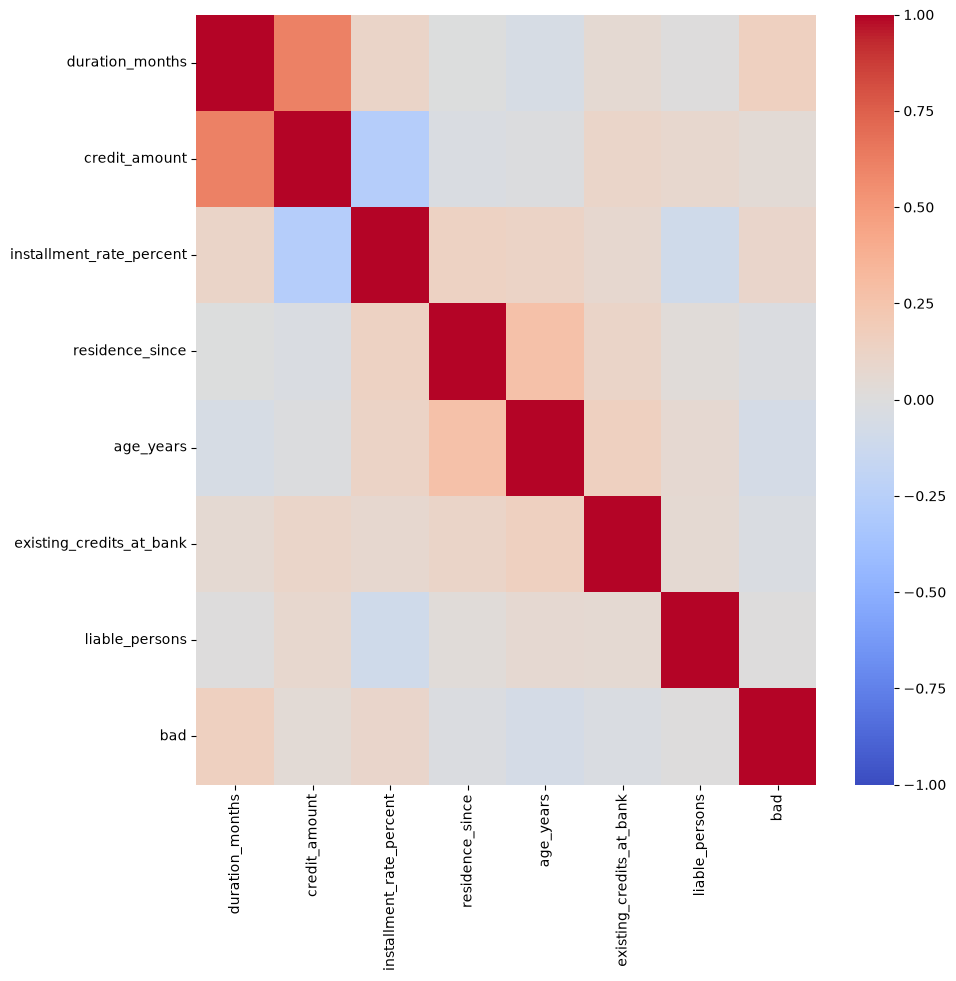

In [8]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 10))
sns.heatmap(
    correlation_matrix,
    # annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.show()

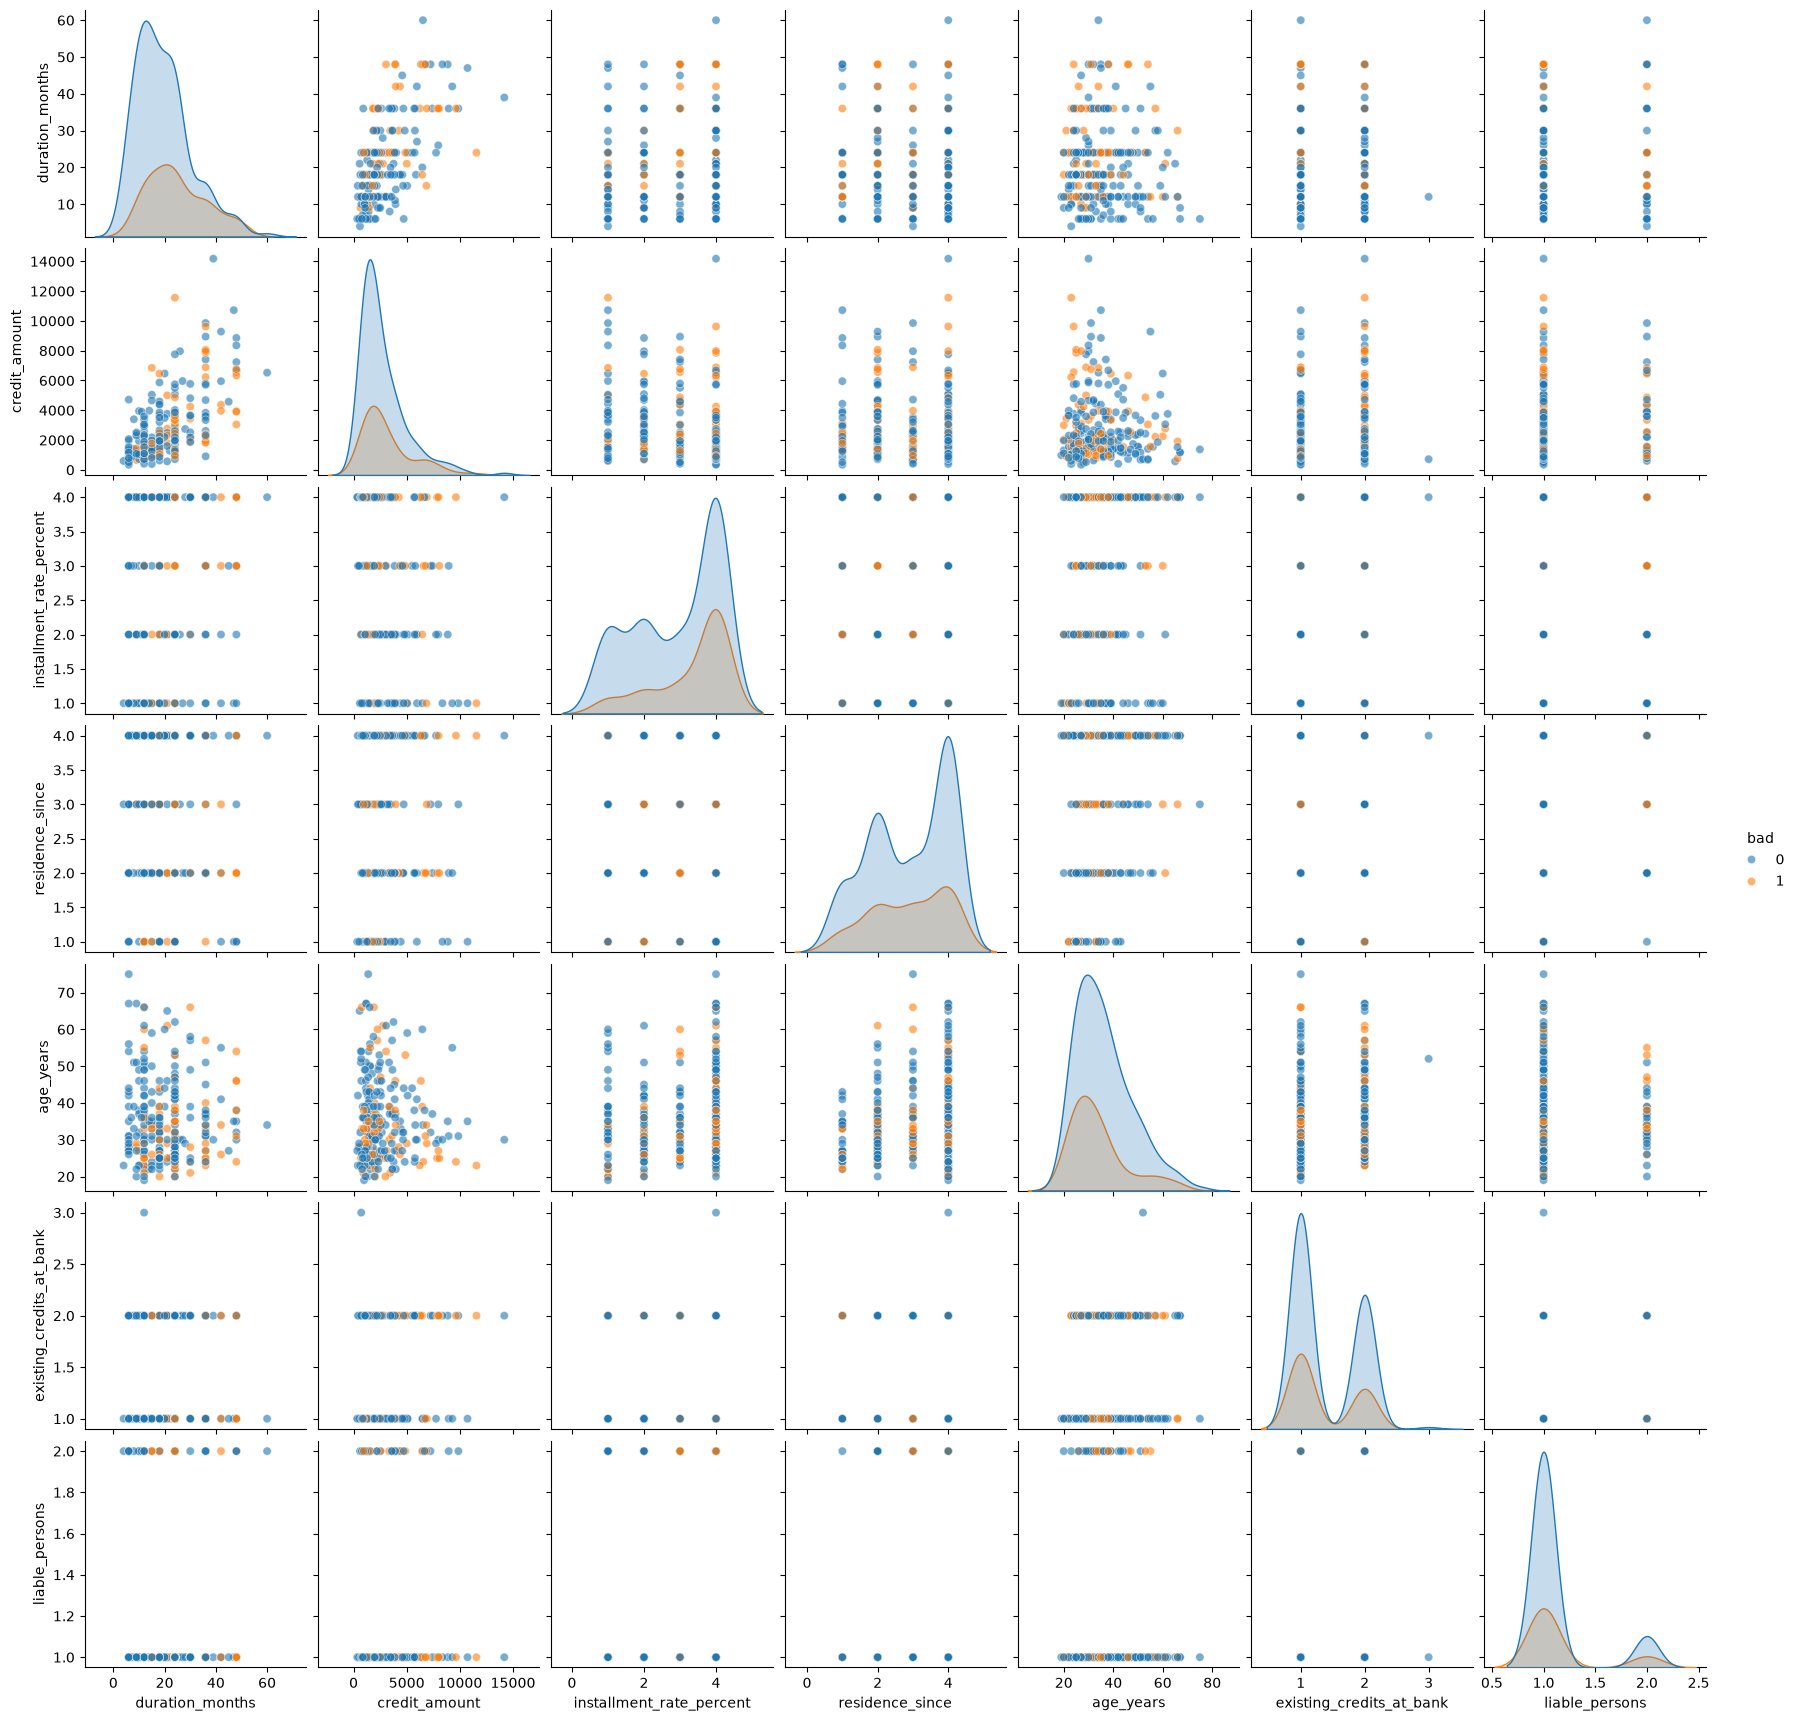

In [9]:
sns.pairplot(
    df.sample(n=250, random_state=42).reset_index(drop=True),
    hue="bad",
    height=2.5,
    diag_kind="kde",
    plot_kws={"alpha": 0.6}
)

plt.show()

# domographics

In [10]:
df.columns

Index(['checking_account_status', 'duration_months', 'credit_history',
       'purpose', 'credit_amount', 'savings_account_bonds', 'employment_since',
       'installment_rate_percent', 'personal_status_sex',
       'other_debtors_guarantors', 'residence_since', 'property', 'age_years',
       'other_installment_plans', 'housing', 'existing_credits_at_bank', 'job',
       'liable_persons', 'telephone', 'foreign_worker', 'bad'],
      dtype='str')

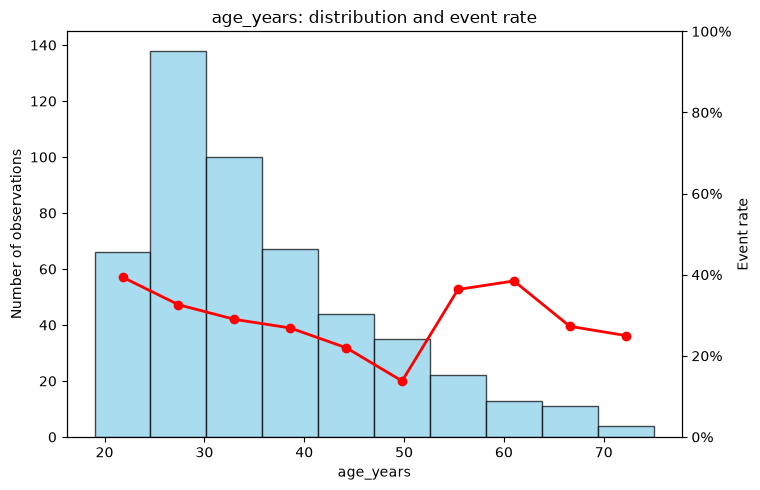

(<Figure size 2100x500 with 4 Axes>,
 array([<Axes: title={'center': 'age_years: distribution and event rate'}, xlabel='age_years', ylabel='Number of observations'>,
        <Axes: >, <Axes: >], dtype=object))

In [11]:
uti.plot_event_num(
    df=df,
    column_names=["age_years"],
    event_column="bad",
    n_bins=10
)

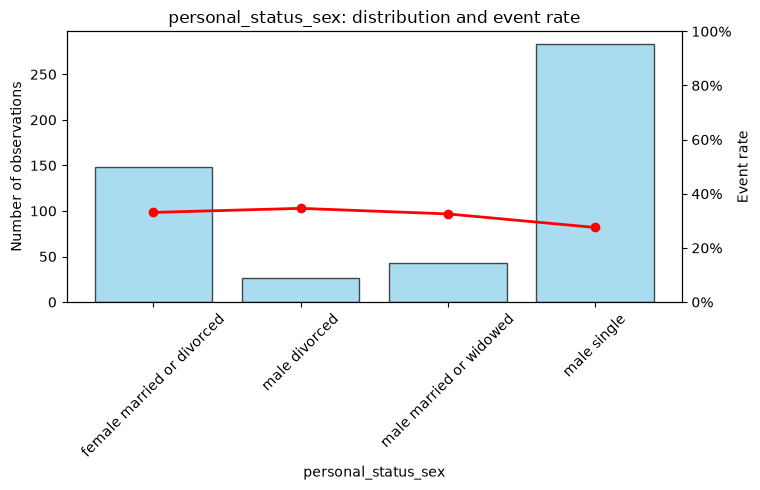

(<Figure size 2100x500 with 4 Axes>,
 array([<Axes: title={'center': 'personal_status_sex: distribution and event rate'}, xlabel='personal_status_sex', ylabel='Number of observations'>,
        <Axes: >, <Axes: >], dtype=object))

In [12]:
uti.plot_event_cat(
    df,
    ['personal_status_sex'],
    event_column="bad"
)

# weight of evidence

In [13]:
df.columns

Index(['checking_account_status', 'duration_months', 'credit_history',
       'purpose', 'credit_amount', 'savings_account_bonds', 'employment_since',
       'installment_rate_percent', 'personal_status_sex',
       'other_debtors_guarantors', 'residence_since', 'property', 'age_years',
       'other_installment_plans', 'housing', 'existing_credits_at_bank', 'job',
       'liable_persons', 'telephone', 'foreign_worker', 'bad'],
      dtype='str')

In [14]:
num_cols = df.select_dtypes(include='number').columns.tolist()
excl = ['bad','age_years']

num_cols = [item for item in num_cols if item not in excl]
num_cols

['duration_months',
 'credit_amount',
 'installment_rate_percent',
 'residence_since',
 'existing_credits_at_bank',
 'liable_persons']

In [15]:
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
excl = ['personal_status_sex']

cat_cols = [item for item in cat_cols if item not in excl]
cat_cols

['checking_account_status',
 'credit_history',
 'purpose',
 'savings_account_bonds',
 'employment_since',
 'other_debtors_guarantors',
 'property',
 'other_installment_plans',
 'housing',
 'job',
 'telephone',
 'foreign_worker']

In [16]:
import toad

combiner = toad.transform.Combiner()

combiner.fit(
    df[num_cols + cat_cols],
    df['bad'],
    method="chi",
    min_samples=0.05
)

In [17]:
X_train_bins = combiner.transform(df[num_cols + cat_cols])
X_test_bins = combiner.transform(df_test[num_cols + cat_cols])

In [18]:
X_train_bins.head()

,duration_months,credit_amount,installment_rate_percent,residence_since,existing_credits_at_bank,liable_persons,checking_account_status,credit_history,purpose,savings_account_bonds,employment_since,other_debtors_guarantors,property,other_installment_plans,housing,job,telephone,foreign_worker
121,2,1,3,1,1,0,0,0,0,2,1,0,1,0,2,0,0,0
260,1,0,1,1,0,0,3,1,2,2,2,0,0,0,0,0,1,0
814,3,2,3,3,0,1,3,1,2,2,0,0,3,0,1,0,1,0
625,1,0,3,1,0,0,0,1,1,0,1,0,1,0,0,0,1,0
280,1,1,2,3,1,0,0,0,0,0,1,0,3,0,2,0,0,0


In [19]:
bin_rules = combiner.export()

print(bin_rules)

{'duration_months': [12, 20, 36], 'credit_amount': [3345, 3914], 'installment_rate_percent': [2, 3, 4], 'residence_since': [2, 3, 4], 'existing_credits_at_bank': [2], 'liable_persons': [2], 'checking_account_status': [['no account'], ['ge200 DM'], ['0 to 200 DM'], ['lt0 DM']], 'credit_history': [['critical or other credit'], ['current credit paid'], ['past payment delays'], ['bank credit paid', 'no credit or all paid']], 'purpose': [['appliances', 'used car'], ['radio or TV', 'other'], ['furniture or equipment', 'business', 'new car'], ['repairs', 'education', 'retraining']], 'savings_account_bonds': [['ge1000 DM', '500 to 1000 DM', 'unknown or no savings'], ['100 to 500 DM'], ['lt100 DM']], 'employment_since': [['4 to 7 years'], ['ge7 years'], ['1 to 4 years'], ['lt1 year'], ['unemployed']], 'other_debtors_guarantors': [['guarantor', 'none', 'co applicant']], 'property': [['real estate'], ['car or other property'], ['life insurance or building society'], ['unknown or no property']], '

In [20]:
woe_transformer = toad.transform.WOETransformer()

woe_transformer.fit(
    X_train_bins,
    df['bad']
)


In [21]:
X_train_woe = woe_transformer.transform(X_train_bins)
X_test_woe = woe_transformer.transform(X_test_bins)

In [22]:
X_train_woe.head()

,duration_months,credit_amount,installment_rate_percent,residence_since,existing_credits_at_bank,liable_persons,checking_account_status,credit_history,purpose,savings_account_bonds,employment_since,other_debtors_guarantors,property,other_installment_plans,housing,job,telephone,foreign_worker
121,0.114930,-0.916291,0.184364,0.006515,-0.091808,0.0,-1.139434,-0.960991,-1.043553,0.311336,-0.310155,0.0,-0.002692,-0.162649,0.580669,0.0,-0.112478,0.0
260,-0.018692,-0.023996,-0.202524,0.006515,0.052368,0.0,0.790945,0.136658,0.210663,0.311336,-0.023056,0.0,-0.400846,-0.162649,-0.215209,0.0,0.069312,0.0
814,0.552498,0.300754,0.184364,-0.021202,0.052368,0.0,0.790945,0.136658,0.210663,0.311336,-0.430363,0.0,0.582605,-0.162649,0.409043,0.0,0.069312,0.0
625,-0.018692,-0.023996,0.184364,0.006515,0.052368,0.0,-1.139434,0.136658,-0.299170,-0.778669,-0.310155,0.0,-0.002692,-0.162649,-0.215209,0.0,0.069312,0.0
280,-0.018692,-0.916291,0.000000,-0.021202,-0.091808,0.0,-1.139434,-0.960991,-1.043553,-0.778669,-0.310155,0.0,0.582605,-0.162649,0.580669,0.0,-0.112478,0.0


## check bins

In [23]:
# Count the number of final bins for each variable
bin_counts = X_train_woe.nunique(dropna=False)
bin_counts

duration_months             4
credit_amount               3
installment_rate_percent    4
residence_since             4
existing_credits_at_bank    2
liable_persons              1
checking_account_status     4
credit_history              4
purpose                     4
savings_account_bonds       3
employment_since            5
other_debtors_guarantors    1
property                    4
other_installment_plans     2
housing                     3
job                         1
telephone                   2
foreign_worker              1
dtype: int64

In [24]:
valid_features = bin_counts[bin_counts > 1].index.tolist()
dropped_features = bin_counts[bin_counts <= 1].index.tolist()

print("Keeping:", valid_features)
print("Dropping:", dropped_features)


Keeping: ['duration_months', 'credit_amount', 'installment_rate_percent', 'residence_since', 'existing_credits_at_bank', 'checking_account_status', 'credit_history', 'purpose', 'savings_account_bonds', 'employment_since', 'property', 'other_installment_plans', 'housing', 'telephone']
Dropping: ['liable_persons', 'other_debtors_guarantors', 'job', 'foreign_worker']


In [25]:
X_train_woe.drop(columns=dropped_features, inplace=True)
X_test_woe.drop(columns=dropped_features, inplace=True)

In [26]:
X_train_woe = X_train_woe.add_suffix("_woe")
X_test_woe = X_test_woe.add_suffix("_woe")

In [27]:
vars_woe = X_train_woe.columns.tolist()

In [28]:
print(X_train_woe.shape)
print(X_test_woe.shape)

(500, 14)
(500, 14)


In [29]:
print(df.shape)
print(df_test.shape)

(500, 21)
(500, 21)


In [30]:
df = pd.concat(
    [df, X_train_woe],
    axis=1
)

df_test = pd.concat(
    [df_test, X_test_woe],
    axis=1
)


In [31]:
print(df.shape)
print(df_test.shape)

(500, 35)
(500, 35)


In [32]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,employment_since,installment_rate_percent,personal_status_sex,other_debtors_guarantors,...,existing_credits_at_bank_woe,checking_account_status_woe,credit_history_woe,purpose_woe,savings_account_bonds_woe,employment_since_woe,property_woe,other_installment_plans_woe,housing_woe,telephone_woe
121,no account,24,critical or other credit,used car,3868,lt100 DM,ge7 years,4,female married or divorced,none,...,-0.091808,-1.139434,-0.960991,-1.043553,0.311336,-0.310155,-0.002692,-0.162649,0.580669,-0.112478
260,lt0 DM,12,current credit paid,furniture or equipment,1657,lt100 DM,1 to 4 years,2,male single,none,...,0.052368,0.790945,0.136658,0.210663,0.311336,-0.023056,-0.400846,-0.162649,-0.215209,0.069312
814,lt0 DM,48,current credit paid,new car,3931,lt100 DM,4 to 7 years,4,male single,none,...,0.052368,0.790945,0.136658,0.210663,0.311336,-0.430363,0.582605,-0.162649,0.409043,0.069312
625,no account,15,current credit paid,radio or TV,1979,unknown or no savings,ge7 years,4,male single,none,...,0.052368,-1.139434,0.136658,-0.299170,-0.778669,-0.310155,-0.002692,-0.162649,-0.215209,0.069312
280,no account,15,critical or other credit,used car,3368,ge1000 DM,ge7 years,3,male single,none,...,-0.091808,-1.139434,-0.960991,-1.043553,-0.778669,-0.310155,0.582605,-0.162649,0.580669,-0.112478


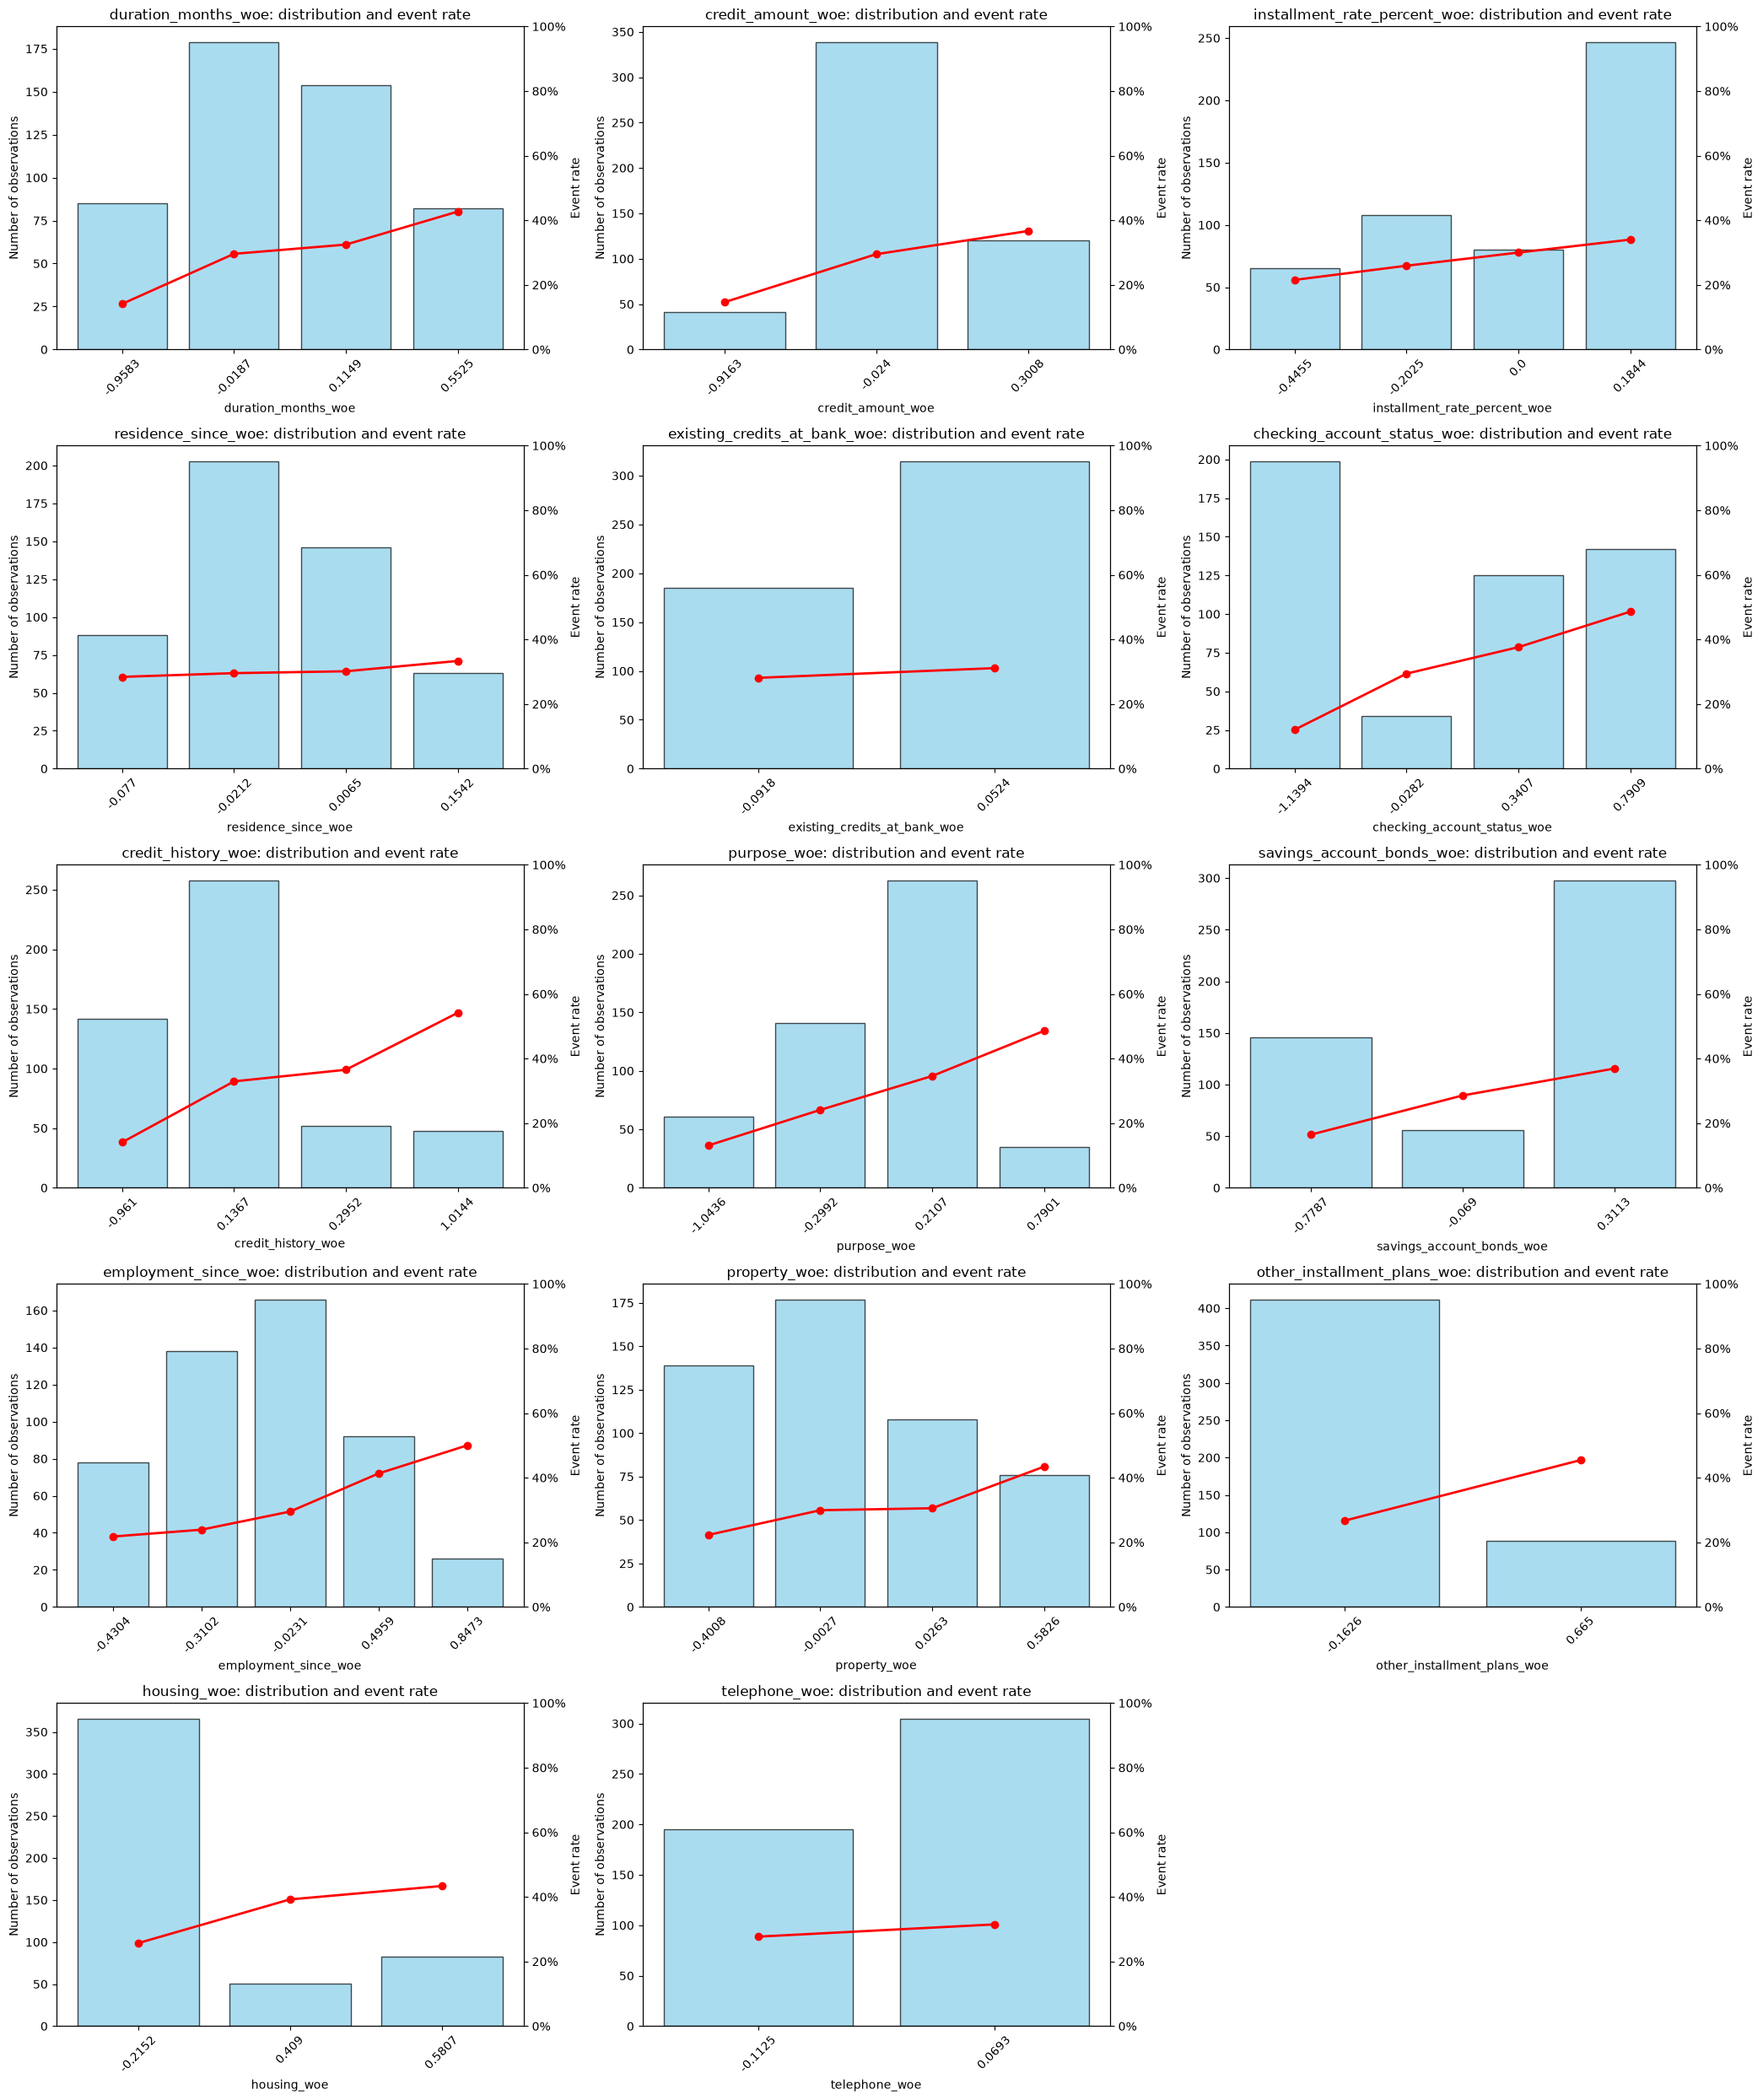

(<Figure size 2100x2500 with 29 Axes>,
 array([<Axes: title={'center': 'duration_months_woe: distribution and event rate'}, xlabel='duration_months_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'credit_amount_woe: distribution and event rate'}, xlabel='credit_amount_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'installment_rate_percent_woe: distribution and event rate'}, xlabel='installment_rate_percent_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'residence_since_woe: distribution and event rate'}, xlabel='residence_since_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'existing_credits_at_bank_woe: distribution and event rate'}, xlabel='existing_credits_at_bank_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'checking_account_status_woe: distribution and event rate'}, xlabel='checking_account_status_woe', ylabel='Number of observations'>,
        <Axes: titl

In [33]:
uti.plot_event_cat(
    pd.concat([df[vars_woe].round(4).astype(object),df['bad']], axis=1),
    vars_woe,
    event_column="bad"
)

## save feature names

In [34]:
feat_names = {}

In [35]:
feat_names['raw'] = num_cols + cat_cols
feat_names['woe'] = vars_woe

In [36]:
feat_names

{'raw': ['duration_months',
  'credit_amount',
  'installment_rate_percent',
  'residence_since',
  'existing_credits_at_bank',
  'liable_persons',
  'checking_account_status',
  'credit_history',
  'purpose',
  'savings_account_bonds',
  'employment_since',
  'other_debtors_guarantors',
  'property',
  'other_installment_plans',
  'housing',
  'job',
  'telephone',
  'foreign_worker'],
 'woe': ['duration_months_woe',
  'credit_amount_woe',
  'installment_rate_percent_woe',
  'residence_since_woe',
  'existing_credits_at_bank_woe',
  'checking_account_status_woe',
  'credit_history_woe',
  'purpose_woe',
  'savings_account_bonds_woe',
  'employment_since_woe',
  'property_woe',
  'other_installment_plans_woe',
  'housing_woe',
  'telephone_woe']}

In [37]:
import pickle

with open("../data/01_dic_feat_names.pkl", "wb") as file:
    pickle.dump(feat_names, file)


# with open("my_dict.pkl", "rb") as file:
#     my_dict = pickle.load(file)

## save woe data

In [38]:
print(df.shape)
print(df_test.shape)

(500, 35)
(500, 35)


In [39]:
df.to_pickle("../data/01_df_train.pkl")
df_test.to_pickle("../data/01_df_test.pkl")


# univariate variable importance

In [40]:
df.info()

<class 'pandas.DataFrame'>
Index: 500 entries, 121 to 747
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   checking_account_status       500 non-null    str    
 1   duration_months               500 non-null    int64  
 2   credit_history                500 non-null    str    
 3   purpose                       500 non-null    str    
 4   credit_amount                 500 non-null    int64  
 5   savings_account_bonds         500 non-null    str    
 6   employment_since              500 non-null    str    
 7   installment_rate_percent      500 non-null    int64  
 8   personal_status_sex           500 non-null    str    
 9   other_debtors_guarantors      500 non-null    str    
 10  residence_since               500 non-null    int64  
 11  property                      500 non-null    str    
 12  age_years                     500 non-null    int64  
 13  other_installment_p

In [41]:
# walds = uti.calculate_wald_statistics(
#     df=df,
#     column_names=feat_names['woe'],
#     event_column="bad"
# )

In [42]:
# saved to wald but its really auc. 

walds= uti.calculate_auc_statistics(
    df=df,
    column_names=feat_names['woe'],
    event_column="bad"
)

In [43]:
walds

,var,auc
0,checking_account_status_woe,0.700714
1,credit_history_woe,0.641429
2,purpose_woe,0.609829
3,savings_account_bonds_woe,0.607543
4,duration_months_woe,0.602352
5,employment_since_woe,0.600190
6,property_woe,0.579390
7,housing_woe,0.576914
8,other_installment_plans_woe,0.564762
9,credit_amount_woe,0.557771


# correlation by importance

In [44]:
# same list but ordered by importance
feat_names['woe'] = walds['var'].tolist()

In [45]:
corr_ranked = df[feat_names['woe']].corr()

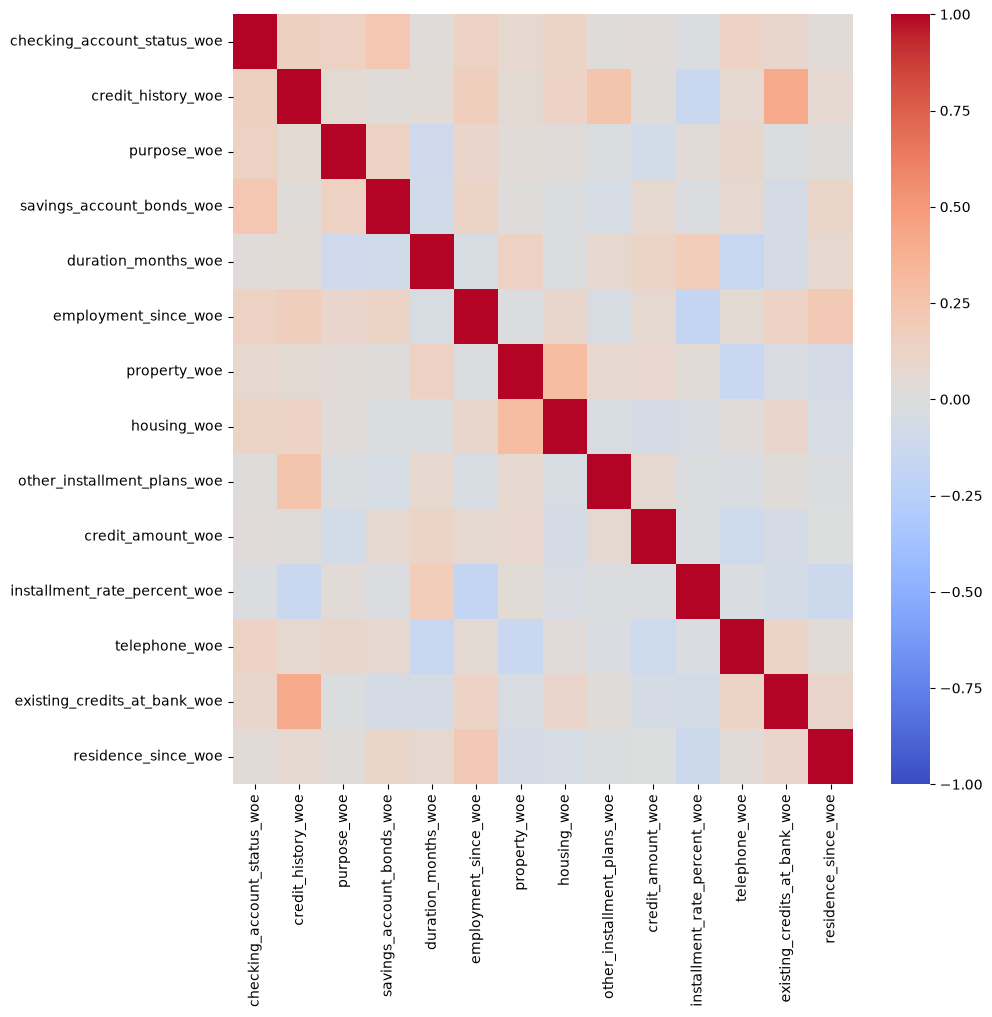

In [46]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    corr_ranked,
    # annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.show()

In [47]:
tmp = uti.corr_crit(corr_ranked,.4)

In [48]:
tmp

,var,corr,corr ind
0,checking_account_status_woe,0.228923,False
1,credit_history_woe,0.414942,True
2,purpose_woe,0.137224,False
3,savings_account_bonds_woe,0.228923,False
4,duration_months_woe,0.181447,False
5,employment_since_woe,0.212169,False
6,property_woe,0.304583,False
7,housing_woe,0.304583,False
8,other_installment_plans_woe,0.247776,False
9,credit_amount_woe,0.118193,False


In [49]:
walds = pd.merge(walds, tmp, on="var", how="left")

In [50]:
walds

,var,auc,corr,corr ind
0,checking_account_status_woe,0.700714,0.228923,False
1,credit_history_woe,0.641429,0.414942,True
2,purpose_woe,0.609829,0.137224,False
3,savings_account_bonds_woe,0.607543,0.228923,False
4,duration_months_woe,0.602352,0.181447,False
5,employment_since_woe,0.600190,0.212169,False
6,property_woe,0.579390,0.304583,False
7,housing_woe,0.576914,0.304583,False
8,other_installment_plans_woe,0.564762,0.247776,False
9,credit_amount_woe,0.557771,0.118193,False


## correlation with criteria

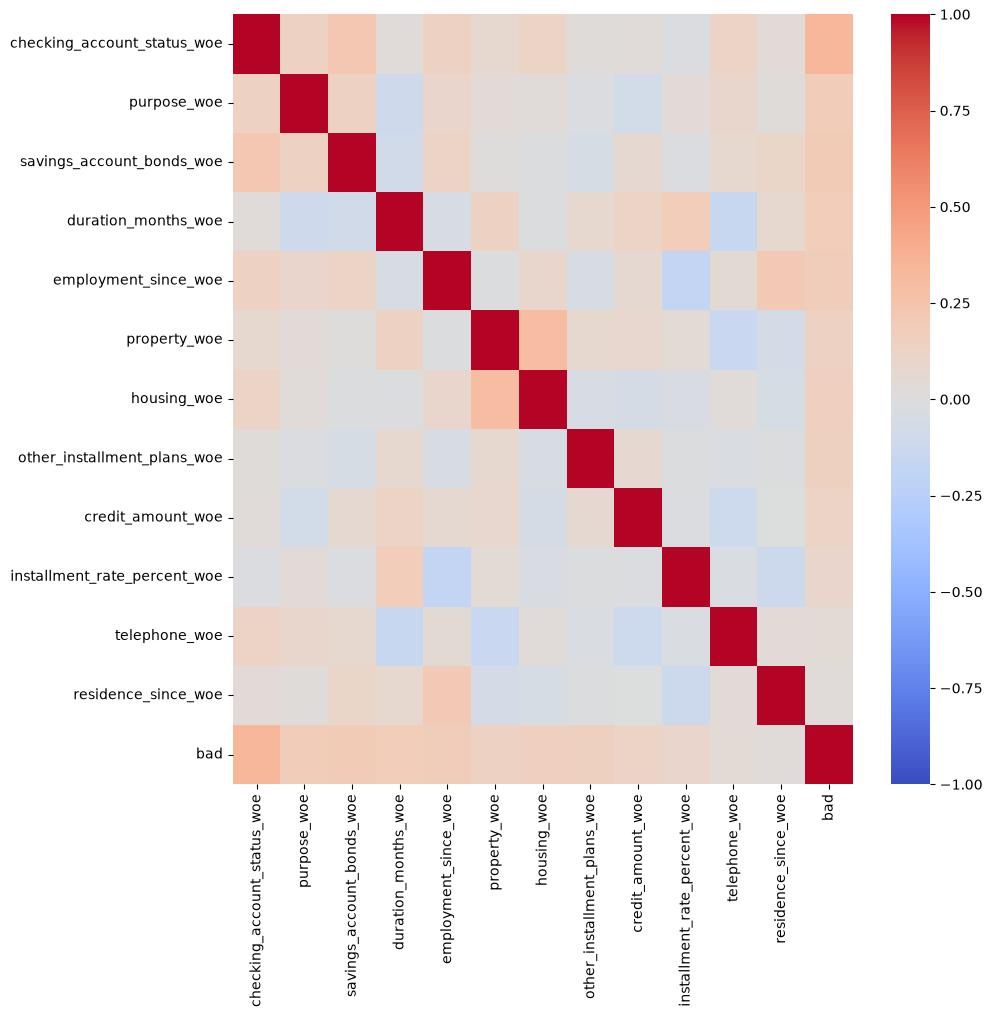

In [51]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    df[walds[walds['corr ind'] == False]['var'].tolist() + ['bad']].corr(),
    # annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.show()

# save wald table

In [52]:
walds.to_pickle("../data/01_df_walds.pkl")